# Logical Pauli — Physical Application vs Pauli-Frame Tracking

**[DEMO]** — protocol is in `lightstim/protocols/logical_pauli.py`; this notebook only imports and demonstrates.

A logical Pauli operator can be implemented two ways (Surface Code Handbook §7.1):

- **physical** — apply the logical X̄/Z̄ string as real gates across the patch. Under circuit-level
  noise the string qubits pick up single-qubit gate noise: extra error locations.
- **frame** — track the operator classically in a Pauli frame (two bits $f_X, f_Z$) and reinterpret
  later measurements. Zero physical cost. In the circuit model this is the same layer tagged
  `noiseless`, so noise injection skips it.

Both modes build gate-for-gate identical clean circuits — the only difference is the noise on the
inserted layer(s). So LER(physical) − LER(frame) isolates exactly the cost of applying the operator
physically. Stacking `num_layers` = N layers amplifies the effect: LER vs N has positive slope for
physical, zero slope for frame.

This demo uses the **rotated surface code** (d=3). Full sweep: `benchmarks/logical_ops/run_logical_ops.py --gate pauli`.

In [1]:
import sys
from pathlib import Path
import io, contextlib

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import stim
import matplotlib.pyplot as plt

from lightstim.protocols.logical_pauli import build_pauli_memory_circuit
from lightstim.qec_code.surface_code.rotated import (
    RotatedSurfaceCode, RotatedSurfaceCodeExtractionBlock)
from lightstim.noise.config import NoiseConfig
from lightstim.simulation.decoder_backend import SimulationPipeline, DecoderConfig

In [2]:
d = 3
p = 1e-3  # physical error rate, p ≈ 1e-3 as in the handbook
noise_params = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)

def build(mode, num_layers=1, rounds=2, noise=None):
    with contextlib.redirect_stdout(io.StringIO()):
        return build_pauli_memory_circuit(
            code_patch_class=RotatedSurfaceCode,
            extraction_block_class=RotatedSurfaceCodeExtractionBlock,
            code_params={"distance": d},
            pauli="X", mode=mode, num_layers=num_layers,
            rounds=rounds, basis="Z", noise_params=noise,
        )

## 1. Circuit

Z-basis memory (rounds = d) with a logical X̄ layer inserted at the midpoint:
`init(Z) → SE×⌈d/2⌉ → X̄ layer → SE×⌊d/2⌋ → readout(Z)`. The X̄ string commutes with every stabilizer
(no detector fires) and anticommutes with the measured Z̄ (the deterministic observable flip
is handled by stim's flip semantics).

In [3]:
circuit_physical = build("physical", num_layers=1, rounds=d, noise=noise_params)
print(f"qubits={circuit_physical.num_qubits}  detectors={circuit_physical.num_detectors}  "
      f"observables={circuit_physical.num_observables}")

qubits=17  detectors=24  observables=1


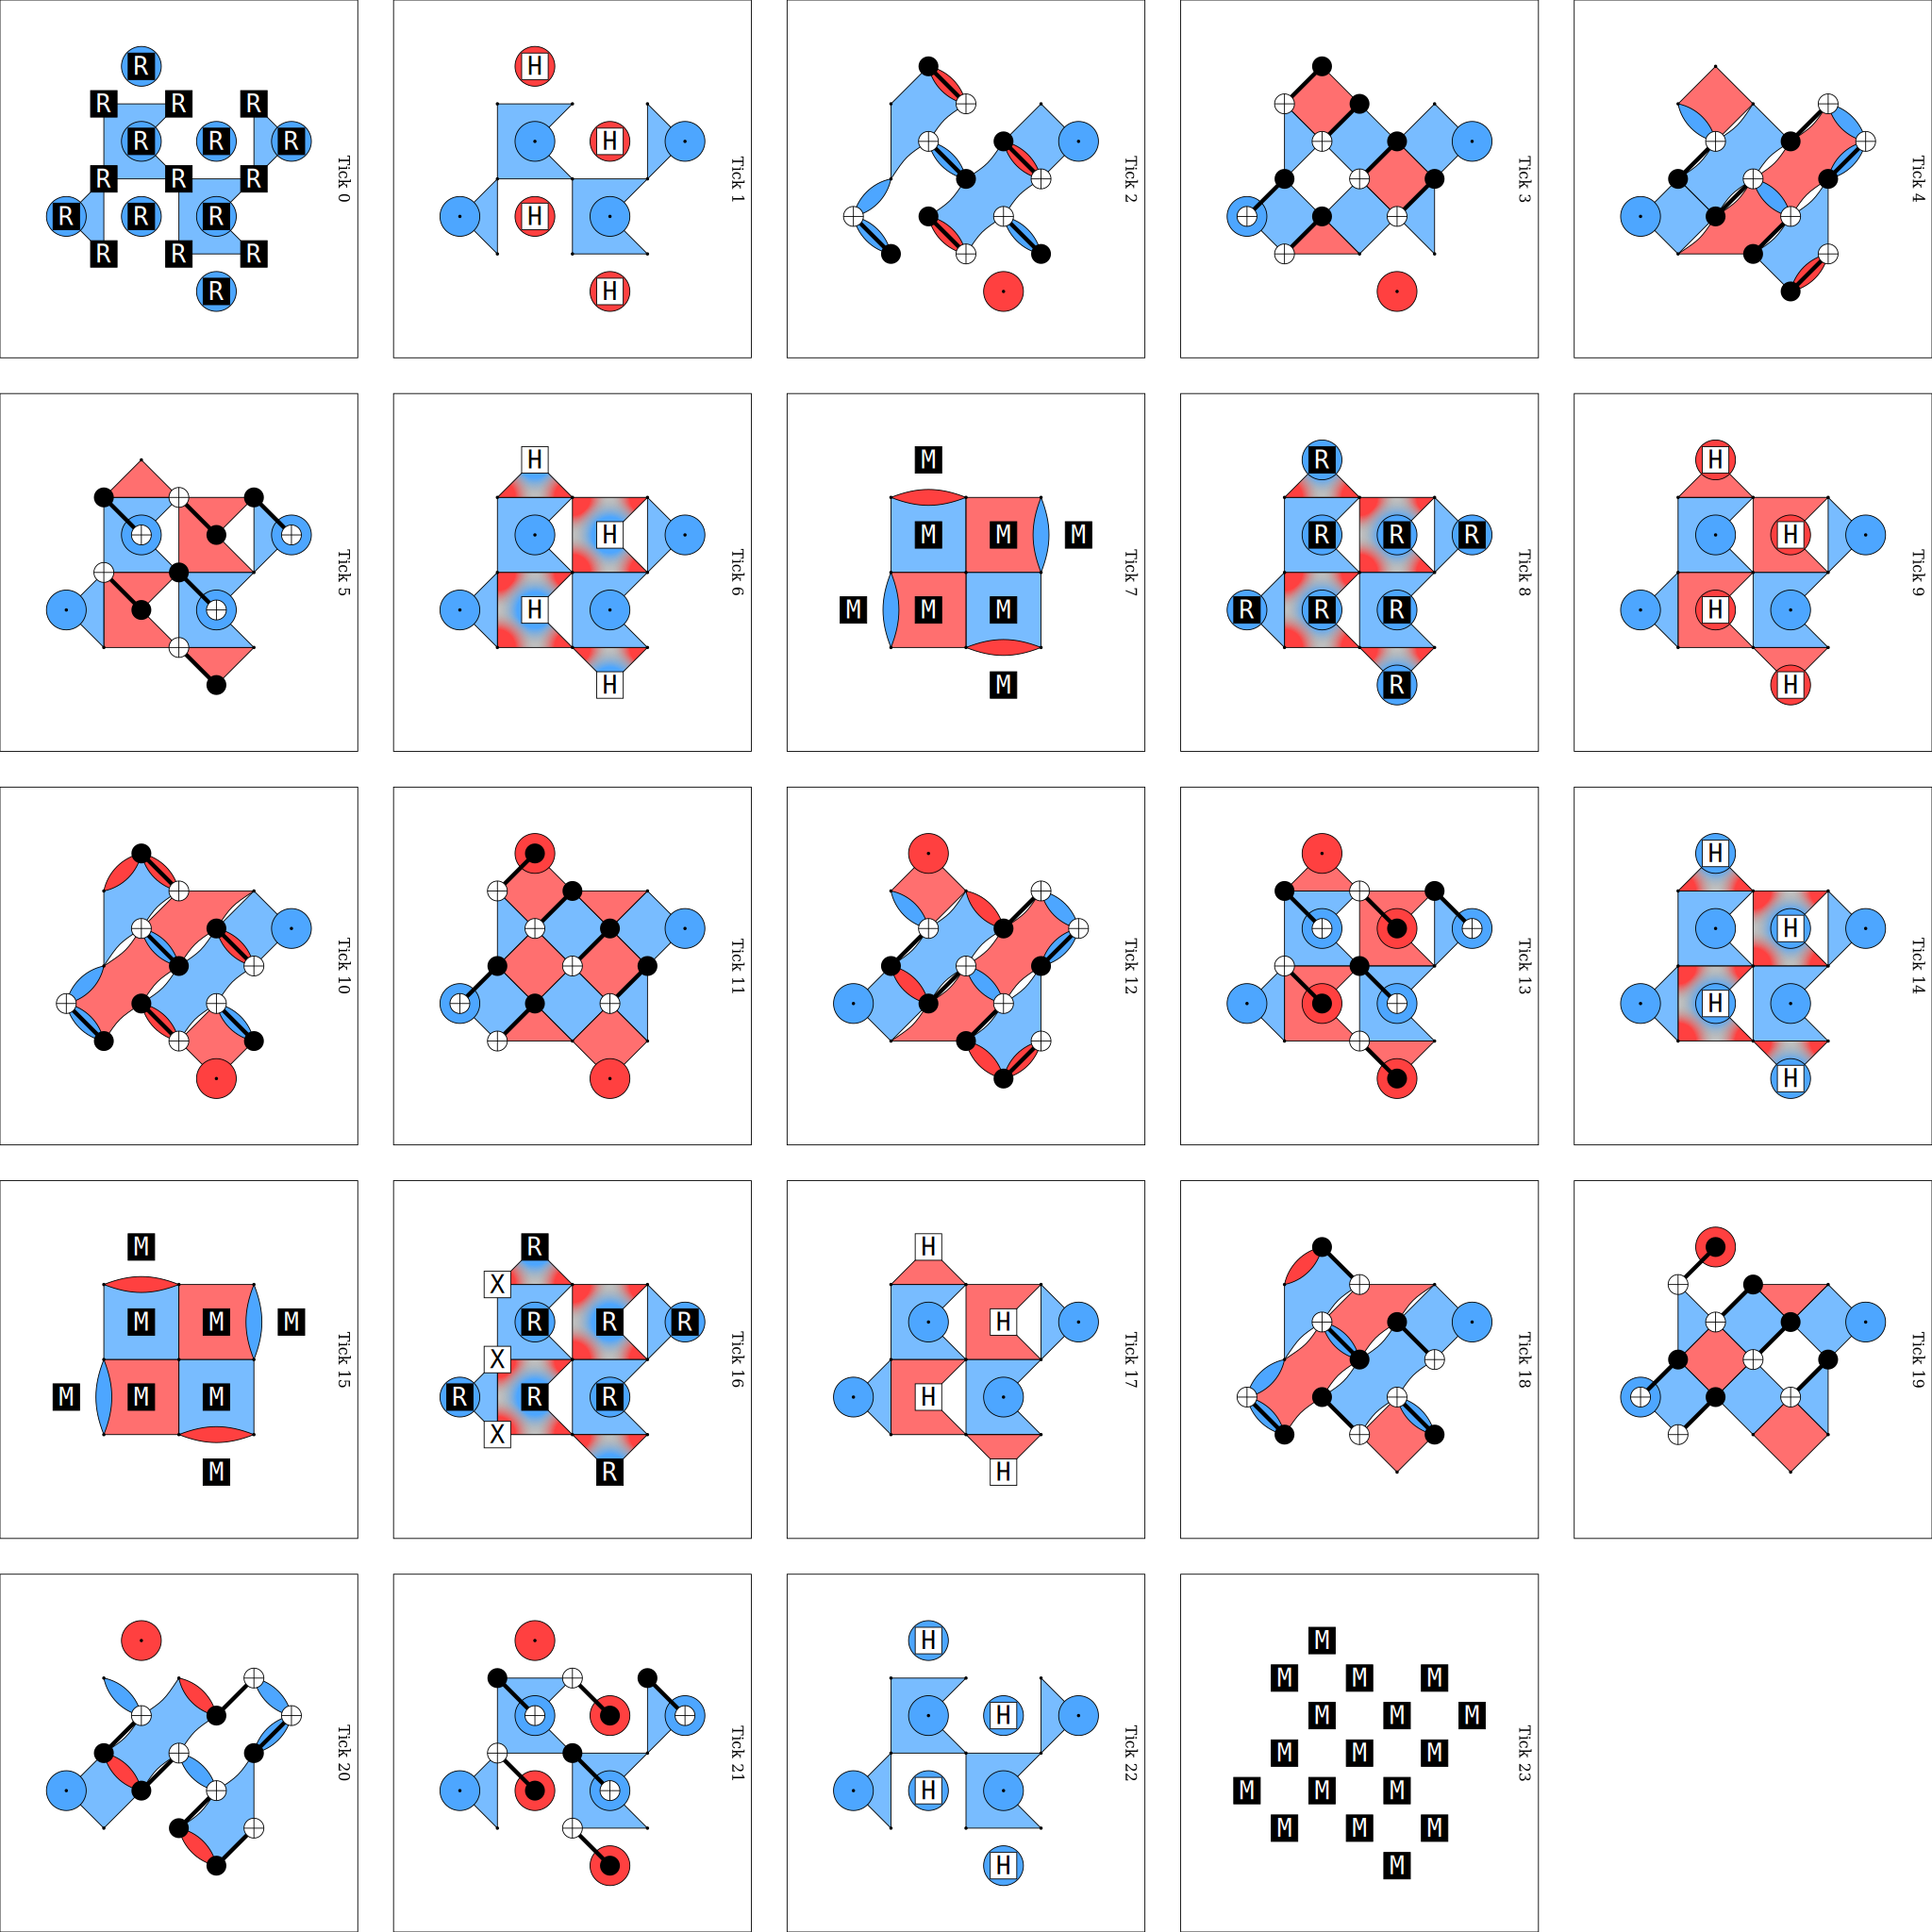

In [4]:
circuit_physical.without_noise().diagram("detslice-with-ops-svg")

## 2. The two arms differ only in the layer noise

Stripped of noise (and of the `noiseless` tag), physical and frame are gate-for-gate identical.
With noise, the physical arm has exactly one extra `DEPOLARIZE1` instruction per inserted layer
— on the weight-d string support.

In [5]:
n_layers = 2
c_phys  = build("physical", num_layers=n_layers, rounds=2, noise=noise_params)
c_frame = build("frame",    num_layers=n_layers, rounds=2, noise=noise_params)

strip = lambda c: stim.Circuit(str(c).replace("[noiseless]", ""))
count_dep1 = lambda c: sum(1 for i in c.flattened() if i.name == "DEPOLARIZE1")

assert strip(c_phys.without_noise()) == strip(c_frame.without_noise())
print("clean circuits identical: OK")
print(f"DEPOLARIZE1 count: physical={count_dep1(c_phys)}, frame={count_dep1(c_frame)} "
      f"(diff = {count_dep1(c_phys) - count_dep1(c_frame)} = num_layers)")

clean circuits identical: OK
DEPOLARIZE1 count: physical=8, frame=6 (diff = 2 = num_layers)


## 3. Noiseless sanity check

Zero detection events and zero observable errors for both modes.

In [6]:
for mode in ("physical", "frame"):
    circ = build(mode, num_layers=1, rounds=2, noise=None)
    dets, obs = circ.compile_detector_sampler(seed=0).sample(500, separate_observables=True)
    print(f"{mode:9s}: detector events={dets.any()}, observable errors={obs.any()}")

physical : detector events=False, observable errors=False
frame    : detector events=False, observable errors=False


## 4. LER vs number of Pauli layers (d=3, physical error rate p ≈ 1e-3, MWPM)

The headline result: the physical arm's LER grows with N (each layer adds error locations),
the frame arm stays flat (classical tracking is free).

In [7]:
pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("pymatching", backend="cpu"),
    max_shots=10_000_000,
    max_errors=20_000,  # non-binding: max_shots is the cap
    num_workers=4,
    print_progress=False,
)

layer_counts = [4, 5, 6, 7, 8]
results = {"physical": [], "frame": []}
for mode in results:
    for n in layer_counts:
        circ = build(mode, num_layers=n, rounds=d, noise=noise_params)
        stats = pipeline.run(circ, {"mode": mode, "N": n})
        results[mode].append(stats.logical_error_rate)
        print(f"{mode:9s} N={n}: LER={stats.logical_error_rate:.2e} "
              f"({stats.errors} errors / {stats.shots:,} shots)")

physical  N=4: LER=1.33e-03 (13277 errors / 10,000,000 shots)


physical  N=5: LER=1.39e-03 (13925 errors / 10,000,000 shots)


physical  N=6: LER=1.41e-03 (14062 errors / 10,000,000 shots)


physical  N=7: LER=1.48e-03 (14797 errors / 10,000,000 shots)


physical  N=8: LER=1.53e-03 (15314 errors / 10,000,000 shots)


frame     N=4: LER=1.16e-03 (11587 errors / 10,000,000 shots)


frame     N=5: LER=1.18e-03 (11759 errors / 10,000,000 shots)


frame     N=6: LER=1.17e-03 (11725 errors / 10,000,000 shots)


frame     N=7: LER=1.16e-03 (11636 errors / 10,000,000 shots)


frame     N=8: LER=1.19e-03 (11928 errors / 10,000,000 shots)


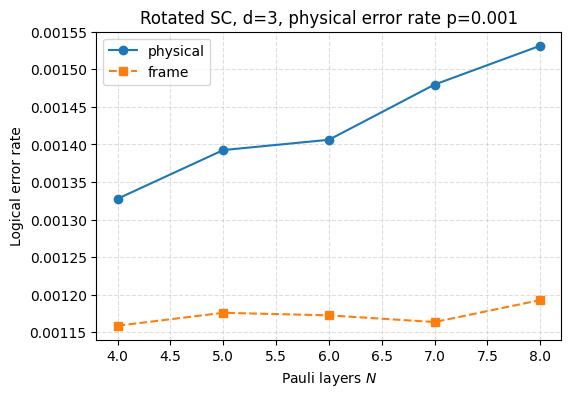

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(layer_counts, results["physical"], "o-",  label="physical")
ax.plot(layer_counts, results["frame"],    "s--", label="frame")
ax.set_xlabel("Pauli layers $N$")
ax.set_ylabel("Logical error rate")
ax.set_title(f"Rotated SC, d={d}, physical error rate p={p:g}")
ax.legend()
ax.grid(True, ls="--", alpha=0.4)
plt.show()

## Takeaway

Physically applying a logical Pauli costs logical fidelity — the per-layer cost shows up as the
slope of the physical curve — while Pauli-frame tracking is free (flat frame curve). This is why
logical Pauli operations are tracked classically in practice.

Note: idle noise in this codebase is lumped once per SE round, so the layer tick carries gate
noise on the weight-d string support only. The measured per-layer cost is therefore a lower
bound on the real physical cost (no spectator idling, no extended duration).